# **Notebook_2: Análisis de componentes principales.**
En este segundo notebook utilizaremos el análisis de componentes principales para analizar la base de datos que contiene números dígitos manuscritos y que se encuentra dentro de la librería scikit-learn. La idea es convertir cada una de las observaciones, que contiene 64 coordenadas en un vector de tamaño mucho menor sin que exista una pérdida significativa de información. Para conocer más acerca de la librería scikit-learn y sus bases de datos, podemos consultar el siguiente link https://scikit-learn.org/stable/

**Importar librerías**: pandas para manejar los datos como dataframes, numpy para realizar operaciones matemáticas, pyplot y seaborn para realizar los gráficos, os, re y pprint para controlar la entrada y salida de datos y finalmente, de scikit-learn, preprocessing para hacer la normalización, decompisition para realizar el procedimiento de PCA y datasets para importar los datos.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os, re
from pprint import pprint

from sklearn.datasets import load_digits

**Cargar el archivo de datos:** Usaremos el conjunto de datos digits.data que contiene los 64 valores para cada dígito, además, digits.target que contiene el dígito que representa cada vector.

In [2]:
digits = load_digits()
data = digits.data
labels=digits.target

**Visualizar datos**: Como cada número está codificado como un vector de 64 posiciones, en donde cada valor indica la intensidad de la imagen, lo podemos convertir en una matriz de 8x8 para visualizarlo correctamente.

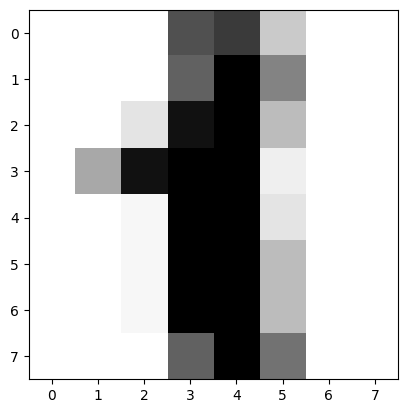

In [4]:
matriz = data[1,:].reshape(8,8)
matriz
plt.imshow(matriz, cmap='Greys')
plt.show()

**Normalización**: Cada uno de los valores de cada posición está en una escala no estándar, por lo tanto, es necesario normalizar los valores para mejorar el resultado del análisis. Usando la función StandardScaler conseguimos que el promedio de cada posición sea 0 y su desviación estándar 1. Esta normalización también ayuda a proyectar desde el subespacio construido con los componentes principales al espacio completo cuando queramos verificar la calidad del proceso.

In [5]:
def get_normed_mean_cov(X):
    X_std = StandardScaler().fit_transform(X)
    X_mean = np.mean(X_std, axis=0)
    X_cov = np.cov(X_std.T)
    return X_std, X_mean, X_cov

X_std, X_mean, X_cov = get_normed_mean_cov(data)

**Visualización de la matriz de covarianzas**: Para el procedimiento de estandarización tuvimos que calcular la matriz de covarianzas para las 64 posiciones de nuestra base de datos, usando la librería seaborn podeos graficar estos resultados.

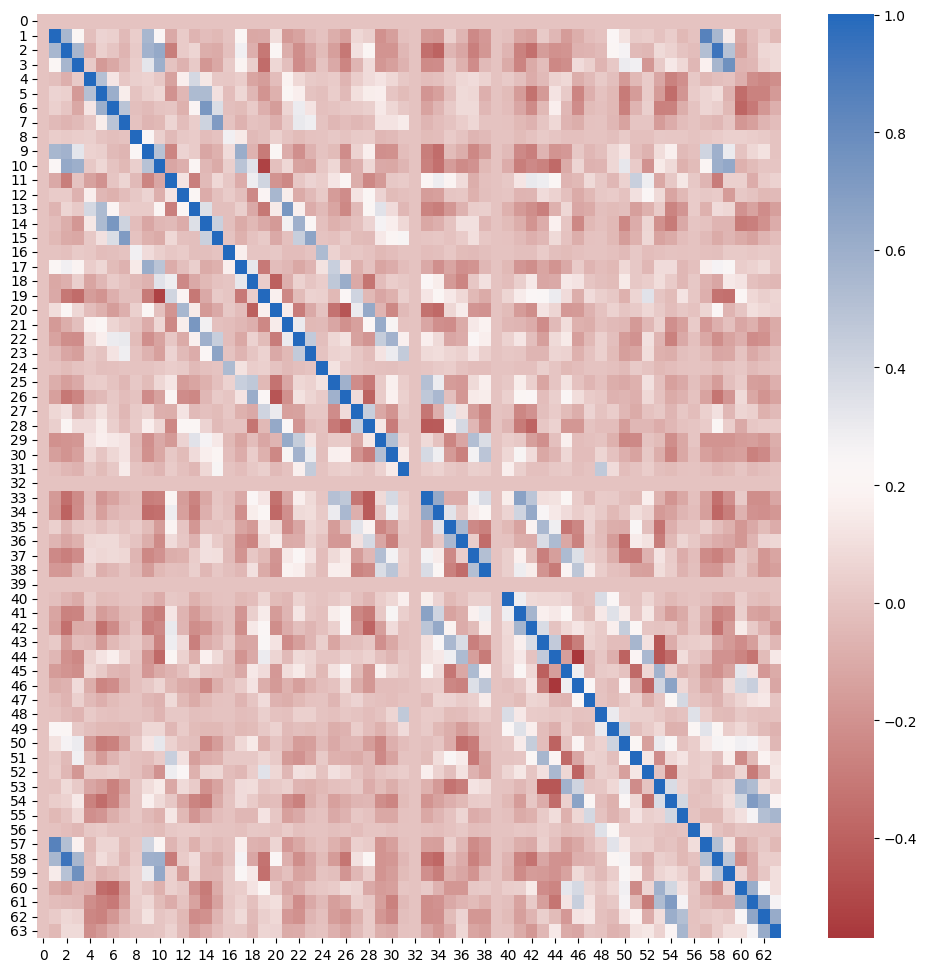

In [6]:
fig = plt.figure(figsize=(12,12))
sns.heatmap(pd.DataFrame(X_cov), annot=False, cmap="vlag_r")
plt.show()

**Análisis**:
Como se observa en la imagen, la mayoría de las covarianzas son negativas, precisamente por la naturaleza de los dígitos y la estructura 8x8 de la codificación de las imágenes. De esta matriz de covarianza vamos a extraer los valores propios y los vectores propios, los cuales son piezas fundamentales en la construcción de los componentes principales.

In [7]:
eigenvals, eigenvecs = np.linalg.eig(X_cov)
print("Eigenvals shape: "+str(eigenvals.shape))
print("Eigenvecs shape: "+str(eigenvecs.shape))

Eigenvals shape: (64,)
Eigenvecs shape: (64, 64)


**Análisis: **
Tenemos 64 valores propios y para cada uno de ellos un vector propio de dimensión 64.

**Ordenar los valores propios**: Vamos a asociar directamente cada vector propio con su respectivo valor propio para luego ordenarlos de mayor a menor con base en el valor absoluto de cada valor propio, luego graficaremos los 64 vectores y para cada uno de ellos los valores propios de mayor peso.

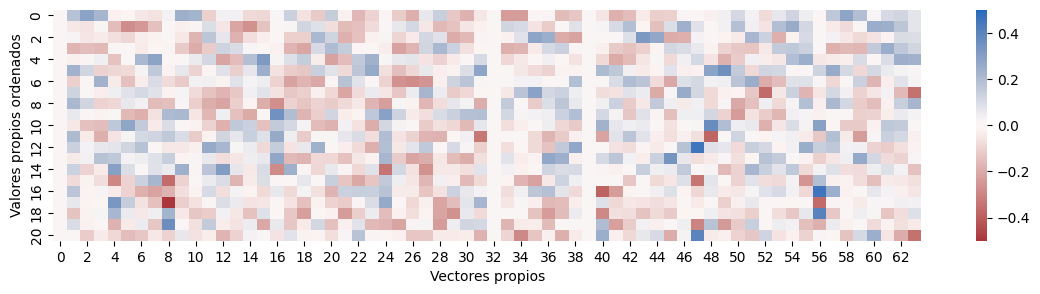

In [8]:
unsrt_eigenvalvec = [(np.abs(eigenvals[i]), eigenvecs[:,i]) for i in range(len(eigenvals))]
eigenvalvec = sorted(unsrt_eigenvalvec, reverse=True, key=lambda x:x[0])
fig = plt.figure(figsize=(14,3))
sns.heatmap(pd.DataFrame([pair[1] for pair in eigenvalvec[0:21]]),
            annot=False, cmap="vlag_r",
           vmin=-0.5,vmax=0.5)

plt.ylabel("Valores propios ordenados")
plt.xlabel("Vectores propios")
plt.show()

**Calcular la varianza explicada**:
Para cada uno de los vectores propios, vamos a calcular el porcentaje de varianza explicada al dividir el valor propio correspondiente sobre la suma de todos los valores propios. Estos resultados los vamos a graficar para poder interpretarlos mejor.

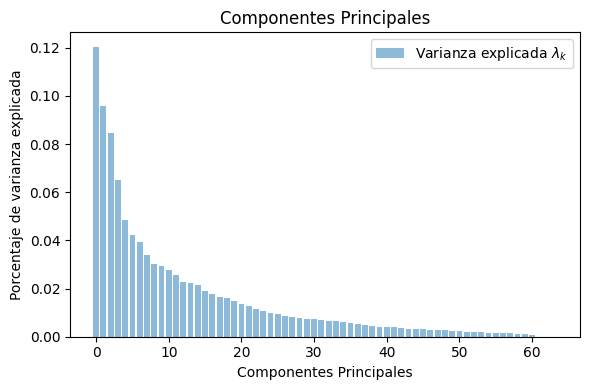

In [9]:
lam_sum = sum(eigenvals)
explained_variance = [(lam_k/lam_sum) for lam_k in sorted(eigenvals, reverse=True)]
plt.figure(figsize=(6, 4))

plt.bar(range(len(explained_variance)), explained_variance, alpha=0.5, align='center',
        label='Varianza explicada $\lambda_{k}$')

plt.ylabel('Porcentaje de varianza explicada')
plt.xlabel('Componentes Principales')
plt.title("Componentes Principales")

plt.legend(loc='best')
plt.tight_layout()

**Análisis**:
En la gráfica anterior podemos observar que el primer componente está explicando, aproximadamente, un 12% de la varianza total, el segundo componente algo más del 9% y el tercero un poco más del 8%. Para tener una mejor valoración del aporte de cada componente al sumarlo al conjunto de componentes principales, se puede calcular la varianza explicada acumulada.

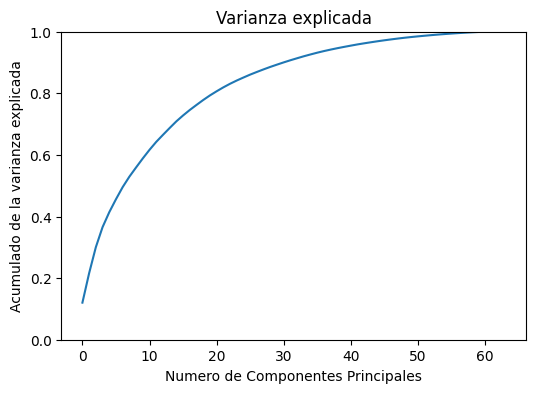

In [10]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.plot(np.cumsum(explained_variance))

ax1.set_ylim([0,1.0])

ax1.set_xlabel('Numero de Componentes Principales')
ax1.set_ylabel('Acumulado de la varianza explicada')
ax1.set_title('Varianza explicada')

plt.show()

**Análisis**:
En la nueva gráfica se ve el aumento marginal en el porcentaje de varianza explicada a medida que se incluyen más componentes, por ejemplo, si usáramos solo tres componentes explicaríamos, aproximadamente, un 30% de la varianza, mientras que con 10 componentes podríamos explicar un poco más del 60% de la varianza, pero se necesitarían 30 componentes (menos de la mitad de la dimensión completa de la base de datos) para explicar un 90% de la varianza.

**Componentes principales:**
Para ilustrar el uso de los componentes principales, vamos a usar los cuatro primeros como conjunto representativo, para ello, usamos el procedimiento de decomposition, fijando el número de componentes en 4.

In [11]:
sklearn_pca = PCA(n_components=4).fit(X_std)
print(sklearn_pca.components_.shape)

(4, 64)


Cada uno de los componentes principales es una combinación lineal de las variables originales de la base de datos, por lo tanto, son de dimensión 64, como los vectores originales. Con la función *components_* se pueden obtener las 64 coordenadas (contribuciones de cada una de las variables originales) para cada uno de ellos.

In [12]:
print("Componentes Principales")
print(sklearn_pca.components_)

Componentes Principales
[[-0.00000000e+00  1.82233917e-01  2.85867997e-01  2.20369669e-01
  -2.51695591e-02 -9.49725041e-03 -5.24764975e-02 -6.26949928e-02
   3.47072724e-02  2.45533684e-01  2.29151737e-01 -1.07943812e-01
   3.62020917e-02  3.87115946e-02 -8.37807734e-02 -9.27750204e-02
   1.66993420e-02  1.36716497e-01 -6.30507547e-02 -1.22879267e-01
   1.48193479e-01 -2.34842464e-02 -1.71199702e-01 -1.04208373e-01
  -3.94881848e-03 -1.16389700e-01 -1.88204732e-01  6.58604010e-02
   1.43532569e-01 -1.28207049e-01 -1.80620749e-01 -5.27091667e-02
  -0.00000000e+00 -2.38902514e-01 -2.35006131e-01 -5.09137360e-03
  -1.31088082e-02 -1.59116182e-01 -1.29394163e-01 -0.00000000e+00
  -5.55990603e-02 -1.87157069e-01 -1.53533710e-01 -4.68257226e-02
  -1.10892715e-01 -1.07209473e-01  1.79265181e-02 -2.27270999e-03
  -2.88172859e-02  4.08680044e-02  1.10270676e-01  3.18243987e-02
  -7.90494506e-02  6.83214736e-02  1.21247066e-01  4.87711942e-02
  -1.83585908e-03  1.60395688e-01  2.79853014e-01  1

Estos valores los vamos a graficar para poder visualizarlos mejor

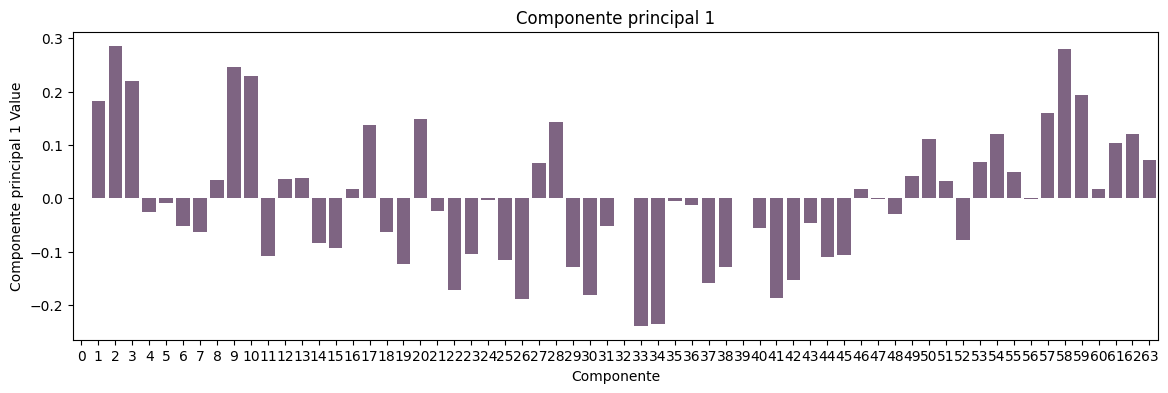

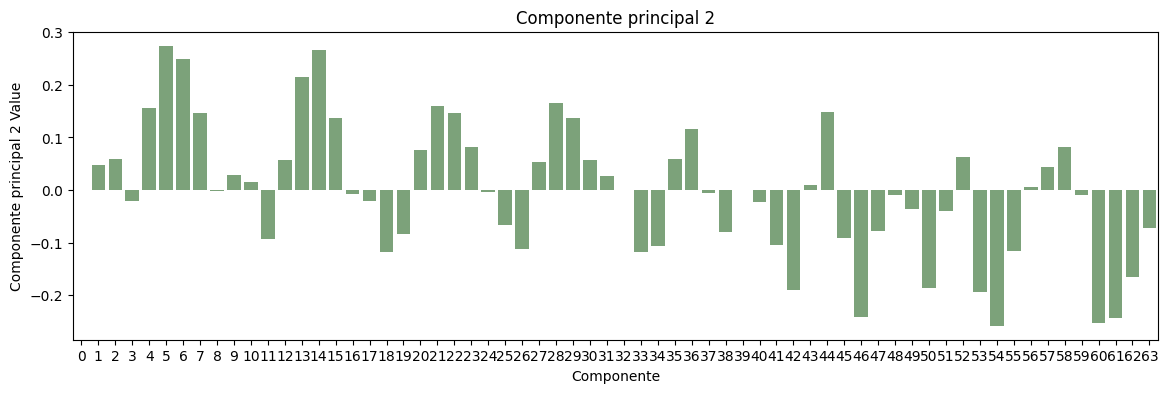

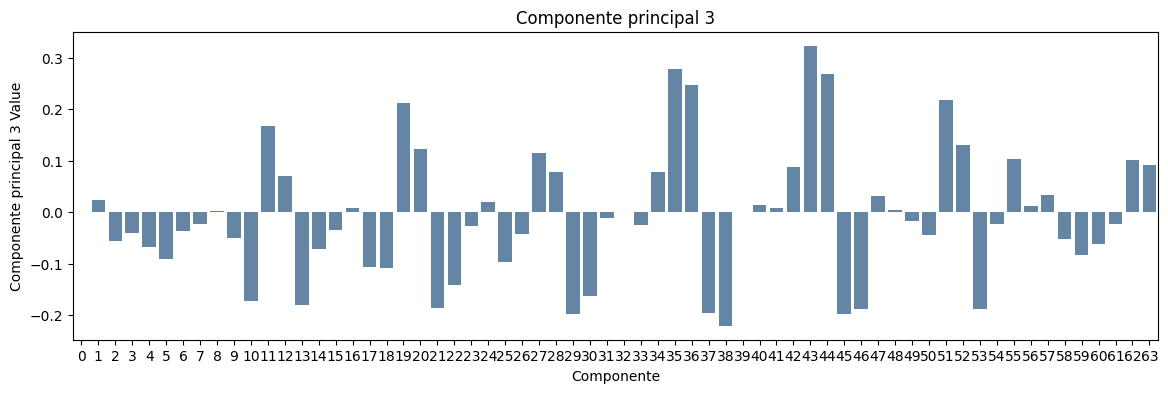

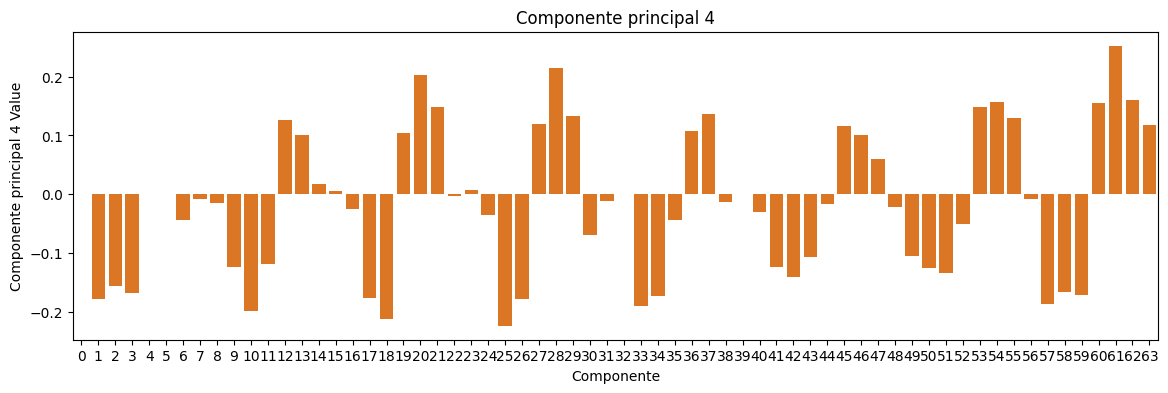

In [14]:
colors = [sns.xkcd_rgb[z] for z in ['dusty purple','dusty green','dusty blue','orange']]
for i in range(4):
    fig = plt.figure(figsize=(14,4))
    sns.barplot(x=list(range(0,64)), y=sklearn_pca.components_[i], color=colors[i])
    plt.xlabel('Componente')
    plt.ylabel('Componente principal '+str(i+1)+' Value')
    plt.title('Componente principal '+str(i+1))
    plt.show()

**Análisis**:

1.   Al observar la gráfica para el primer componente, se observa que las variables que más aportan son las que se encuentran en las posiciones 3 (índice 2 del vector) y 59 (índice 58 del vector) con pesos de -0.286 y -0.280, respectivamente.  
2.   Para el componente 2, las variables que más aportan son las que se encuentran en las posiciones 6 (índice 5 del vector) y 15 (índice 14 del vector) con pesos de 0.274 y 0.267, respectivamente.  
3.   Para el componente 3, las variables que más aportan son las que se encuentran en las posiciones 44 (índice 43 del vector) y 36 (índice 35 del vector) con pesos de 0.323 y 0.277, respectivamente.
4.   finalmente, para el componente 4, las variables que más aportan son las que se encuentran en las posiciones 62 (índice 61 del vector) y 26 (índice 25 del vector) con pesos de 0.252 y 0.223, respectivamente.




Adicionalmente, como los datos originales representan una matriz de 8x8, se pueden graficar los componentes de esa forma para ver más claramente cuales pixeles son importantes en cada uno de los componentes.

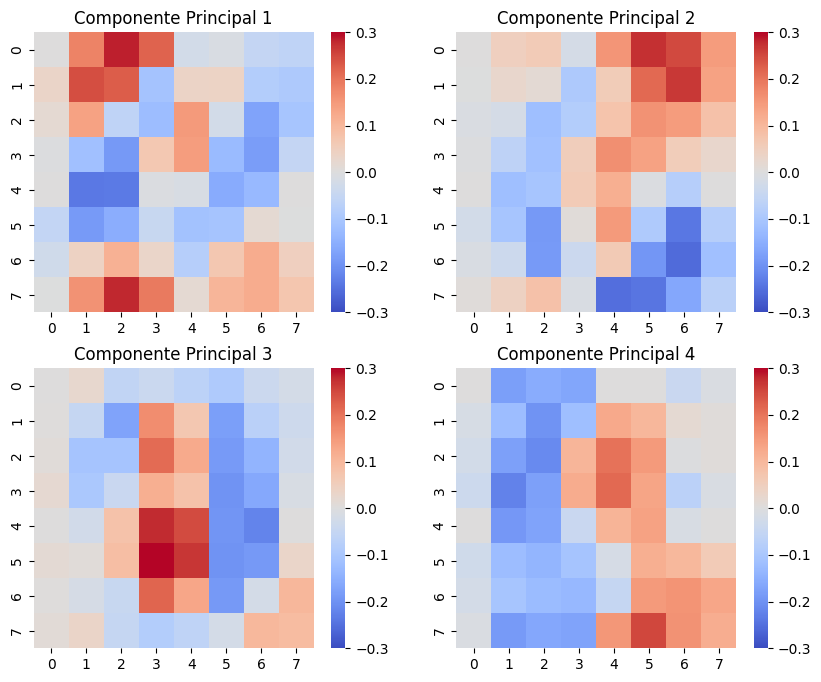

In [15]:
fig = plt.figure(figsize=(10,8))
axes = [fig.add_subplot(220+i+1) for i in range(4)]

for i,ax in enumerate(axes):
    sns.heatmap(sklearn_pca.components_[i].reshape(8,8),
                square=True, ax=ax, cmap='coolwarm',
                vmax = 0.30, vmin=-0.30)
    ax.set_title('Componente Principal '+str(i+1))

plt.show()

Ahora, utilizando el comando cumsum, podemos obtener de nuevo el porcentaje de varianza explicada por los cuatro componentes utilizados, pero además, podemos hacer ese cálculo para diferentes tamaños de la base transformada y obtendremos los resultados ya discutidos para el gráfico del acumulado de la varianza explicada.

In [16]:
print(np.cumsum(explained_variance)[4])

0.4139794817694791


In [17]:
pprint([(j, np.cumsum(explained_variance)[j]) for j in range(len(explained_variance[:64]))])

[(0, np.float64(0.12033916097734892)),
 (1, np.float64(0.21594970500832764)),
 (2, np.float64(0.30039385393457313)),
 (3, np.float64(0.3653779330098148)),
 (4, np.float64(0.4139794817694791)),
 (5, np.float64(0.45612068046219867)),
 (6, np.float64(0.4955415084978725)),
 (7, np.float64(0.5294353177442558)),
 (8, np.float64(0.5594175278605082)),
 (9, np.float64(0.5887375533730302)),
 (10, np.float64(0.6165556080085336)),
 (11, np.float64(0.6423261589343535)),
 (12, np.float64(0.665079192091996)),
 (13, np.float64(0.6873509894871392)),
 (14, np.float64(0.7090032838056316)),
 (15, np.float64(0.728144949870053)),
 (16, np.float64(0.7459004207217352)),
 (17, np.float64(0.7622811134645795)),
 (18, np.float64(0.7782457151532032)),
 (19, np.float64(0.7931376270240814)),
 (20, np.float64(0.8066173226822607)),
 (21, np.float64(0.8193366363846084)),
 (22, np.float64(0.8309950098905279)),
 (23, np.float64(0.8415714758758911)),
 (24, np.float64(0.8513246353478722)),
 (25, np.float64(0.86077022524519

**Proyección en el subespacio**:
Una forma de evaluar, al menos cualitativamente, la  calidad del subconjunto de componentes utilizados, es a través de los gráficos de proyección en los subespacios, teniendo en cuenta que se tiene conocimiento del dígito real que representa cada observación, podemos graficar, con colores diferentes para cada dígito, en espacios bidimensionales usando dos de los componentes hallados. Entre mejor se formen los clusters de cada dígito, mejor la calidad del subconjunto seleccionado.


In [18]:
scikit_Z = sklearn_pca.fit_transform(X_std)
print(scikit_Z.shape)

(1797, 4)


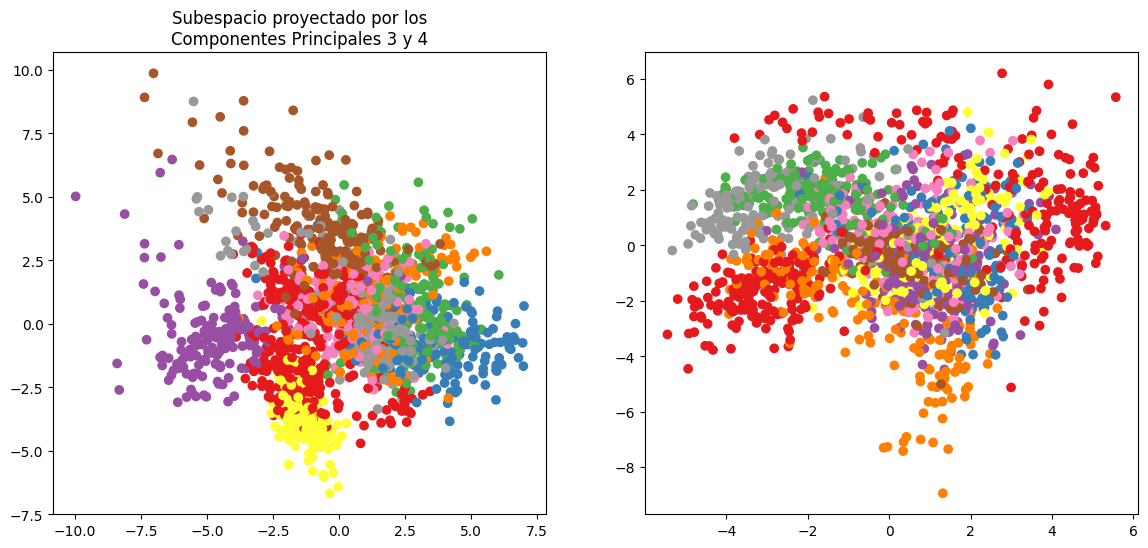

Varianza explicada del Componente Principal 1: 0.3294
Varianza explicada del Componente Principal 2: 0.2617
Varianza explicada del Componente Principal 3: 0.2311
Varianza explicada del Componente Principal 4: 0.1779


In [19]:
fig = plt.figure(figsize=(14,6))
ax1, ax2 = [fig.add_subplot(120 + i + 1) for i in range(2)]

def get_cmap(n):
    #colorz = plt.cm.cool
    colorz = plt.get_cmap('Set1')
    return[ colorz(float(i)/n) for i in range(n)]

colorz = get_cmap(10)
colors = [colorz[yy] for yy in labels]

ax1.scatter( scikit_Z[:,0], scikit_Z[:,1] , c=colors )
ax1.set_title('Subespacio proyectado por los\nComponentes Principales 1 y 2')

ax2.scatter( scikit_Z[:,2], scikit_Z[:,3] , c=colors )
ax1.set_title('Subespacio proyectado por los\nComponentes Principales 3 y 4')

plt.show()

for i in range(4):
    print("Varianza explicada del Componente Principal %d: %0.4f"%(i+1,sklearn_pca.explained_variance_[i]/np.sum(sklearn_pca.explained_variance_.sum())))

**Análisis**:
Las gráficas que obtuvimos, nos muestran que cada grupo (color) está debidamente agrupado, sin embargo, existen traslapes que dificultan la identificación de un único dígito para cada observación. Además, para cada componente se cálculo la proporción, relativa a la varianza explicada por los cuatro componentes seleccionados, de varianza explicada, con la cual, podemos observar que el componente 1 explica casi una tercera parte de la varianza que explican los cuatro componentes. Estos gráficos bidimensionales, se pueden hacer con todas las parejas que se pueden formar con los cuatro componentes, como se muestra en la figura a continuación, sin embargo, los resultados son similares a los discutidos para los dos primeros gráficos.

In [20]:
pairplot_df = pd.DataFrame(scikit_Z, columns=['Componente Principal '+str(j+1) for j in range(scikit_Z.shape[1])])
pairplot_df.reindex(pairplot_df.columns.sort_values(ascending=True))
z_columns = pairplot_df.columns

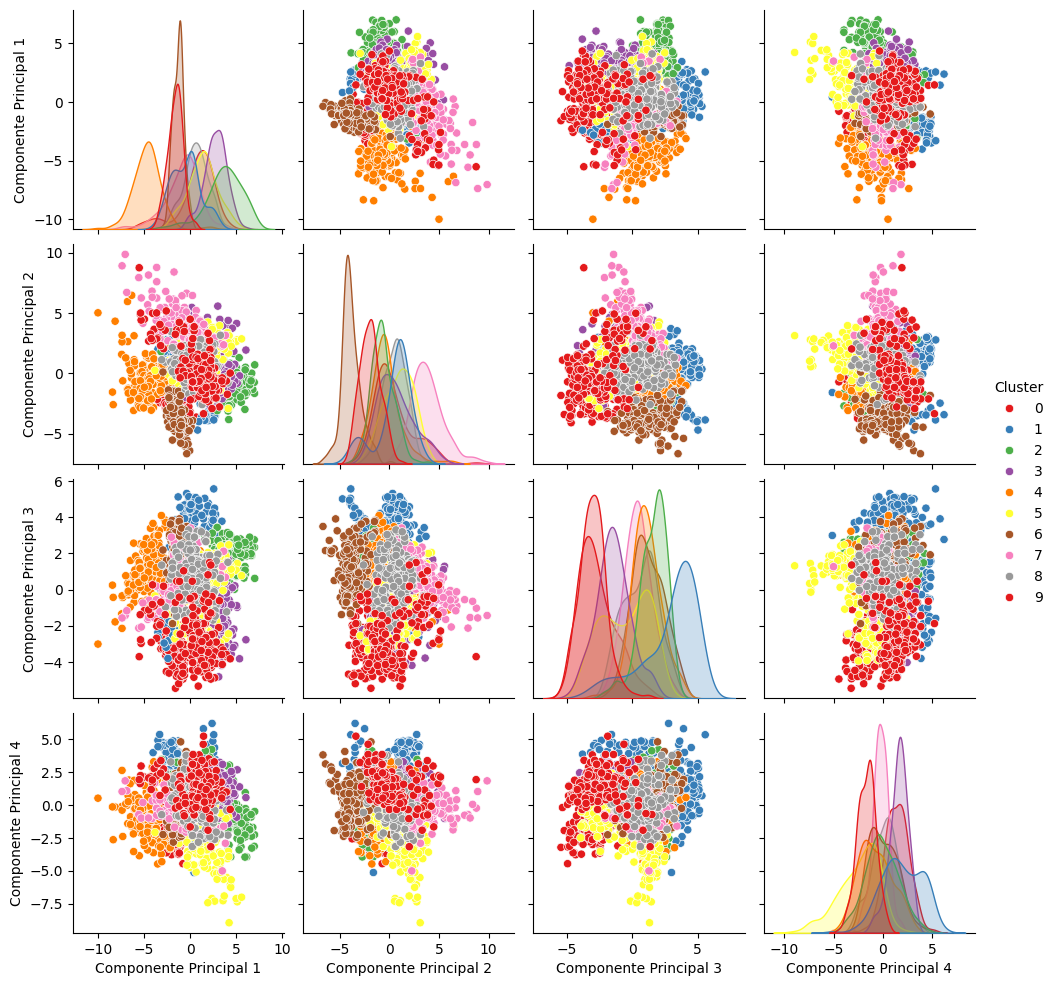

In [21]:
pairplot_df['Cluster'] = labels
pairplot_df = pairplot_df.sort_values('Cluster',ascending=True)
sns.pairplot(pairplot_df, hue='Cluster',
             vars=z_columns, # don't plot the category/system response
             palette='Set1')
plt.show()

**Visualización en el espacio original (proyección inversa)**:
Una forma directa de evaluar la información que contiene el grupo de cuatro componentes principales seleccionados, es a través de la proyección del subespacio definido por estos componentes en el espacio original de alta dimensionalidad. Lo cual se logra con la transformación inversa. Los resultados para la primera observación, se muestran a continuación.

In [24]:
matW = np.hstack([pair[1].reshape(64,1) for pair in eigenvalvec[0:4]])
print(matW.shape)

(64, 4)


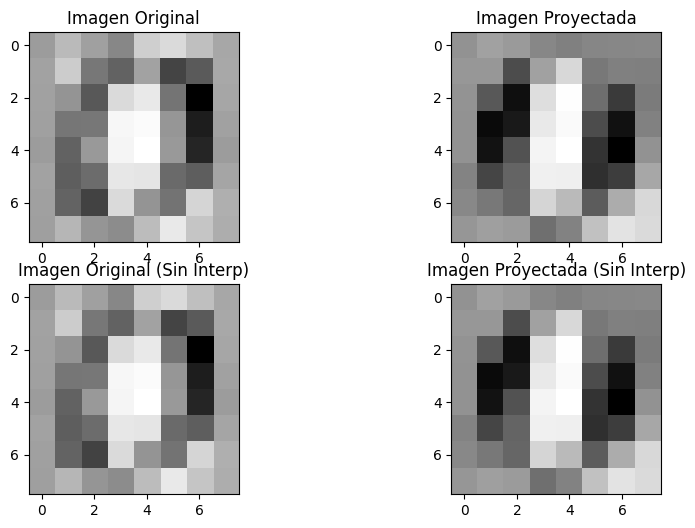

In [25]:
X_digit1 = X_std[0]
Z_digit1 = X_digit1.dot(matW)
Xhat_digit1 = Z_digit1.dot(matW.T)

fig = plt.figure(figsize=(10,6))
ax1, ax2, ax3, ax4 = (fig.add_subplot(221+i) for i in range(4))



ax1.imshow(X_digit1.reshape(8,8), cmap='Greys')
ax1.set_title('Imagen Original')

ax2.imshow(Xhat_digit1.reshape(8,8), cmap='Greys')
ax2.set_title('Imagen Proyectada')



ax3.imshow(X_digit1.reshape(8,8),
             interpolation = "none", cmap='Greys')
ax3.set_title('Imagen Original (Sin Interp)')


ax4.imshow(Xhat_digit1.reshape(8,8),
             interpolation = "none", cmap='Greys')
ax4.set_title('Imagen Proyectada (Sin Interp)')

plt.show()

**Análisis:**
Como se puede observar en las imágenes anteriores, la reducción de dimensiones conservó, al menos para este caso, una parte significativa de la información codificada en cada matriz de pixeles, ya sea interpolando o sin interpolación, se encuentran similitudes significativas entre las imágenes originales y las reconstruidas. Este proceso se realizó para otras imágenes y los resultados son similares a los de la primera observación.

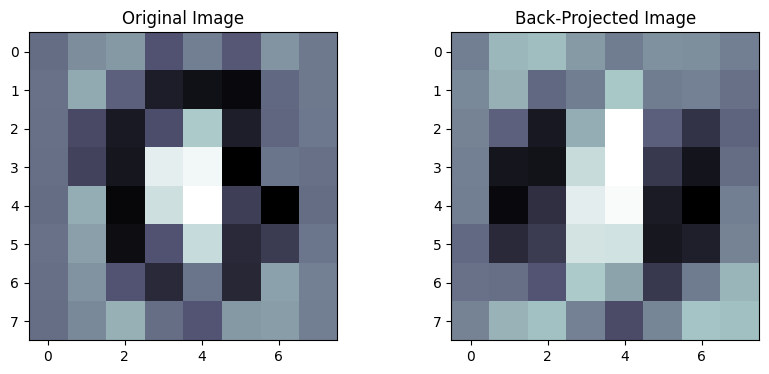

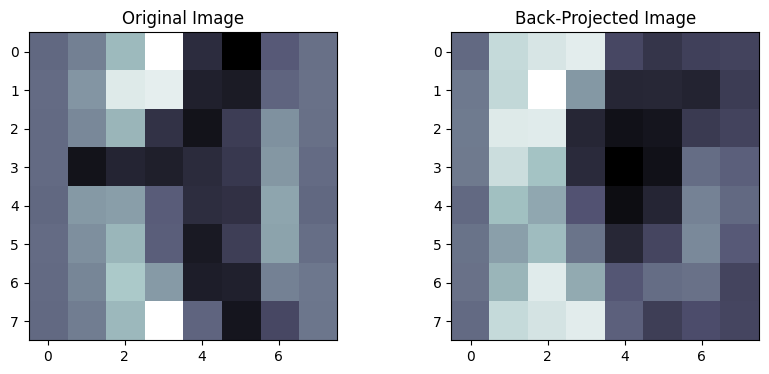

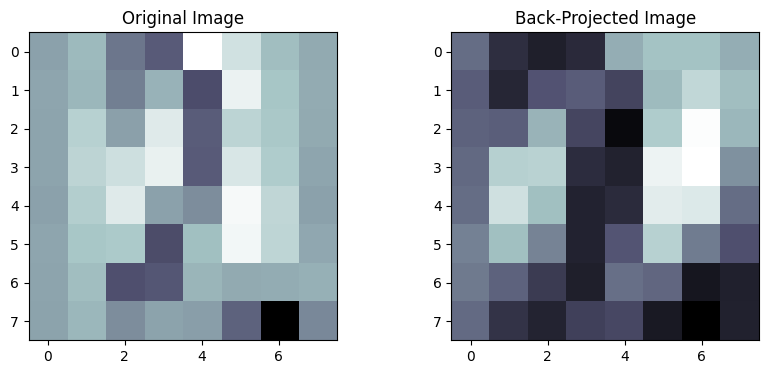

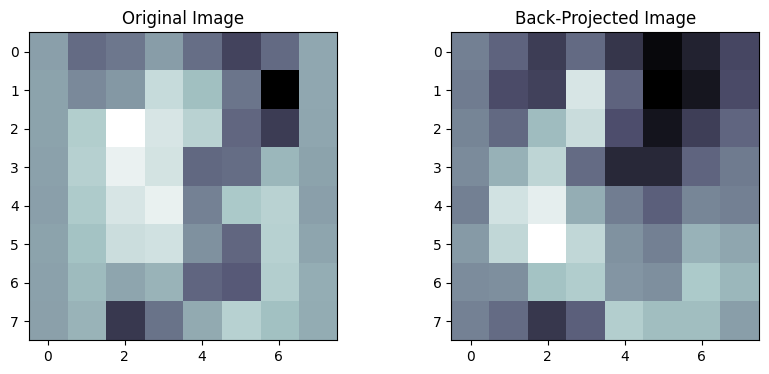

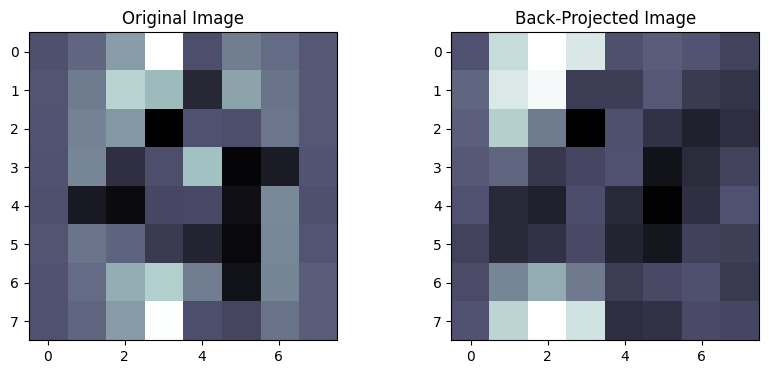

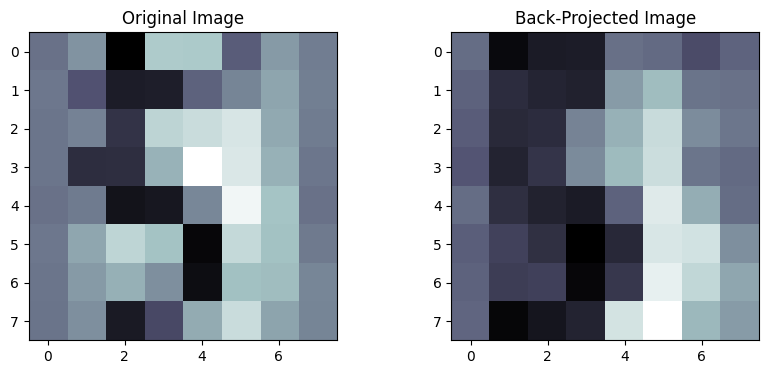

In [26]:
for j in range(6):
    X_digit = X_std[j+20]
    Z_digit = X_digit.dot(matW)
    Xhat_digit = Z_digit.dot(matW.T)

    fig = plt.figure(figsize=(10,4))
    ax1, ax2 = (fig.add_subplot(121+i) for i in range(2))

    ax1.imshow(X_digit.reshape(8,8),
              cmap = "bone_r")
    ax1.set_title('Original Image')

    ax2.imshow(Xhat_digit.reshape(8,8),
              cmap = "bone_r")
    ax2.set_title('Back-Projected Image')

plt.show()

**Métricas de eficiencia**:
Para evaluar de forma cuantitativa la preservación, o pérdida, de información al reducir la dimensionalidad de la base de datos, se pueden definir métricas de eficiencia, tales como el MSE (error cuadrático medio) y el coeficiente de determinación R^2, que junto con el porcentaje de varianza explicada, nos permite valorar la eficiencia del procedimiento.

In [27]:
X_hat = sklearn_pca.inverse_transform( sklearn_pca.transform(X_std) )

mse = ((X_hat - X_std)**2).mean(axis=None)
print(mse)
print(1-mse)

0.6048741576000207
0.3951258423999793


In [28]:
print(np.cumsum(explained_variance)[:4])

[0.12033916 0.21594971 0.30039385 0.36537793]


**Análisis**:
El MSE para este caso, recordemos que las variables fueron normalizadas, fue de 0.605 y su complemento, equivalente al R^2, es de 0.395, lo que o difiere significativamente del porcentaje de varianza explicada obtenida con el cumsum, que fue igual al 36.53%.

Ahora, para completar el análisis, podemos calcular estos valores en función del número de componentes a utilizar y graficar estos resultados, como se muestra a continuación.

In [29]:
def pca_mse(n):
    # Make PCA
    pca = PCA(n_components=n, whiten=True)
    pca.fit(X_std)
    X_red = pca.transform(X_std)

    # MSE associated with back-projection:
    X_orig = X_std
    X_hat = pca.inverse_transform( pca.transform(X_orig) )
    mse = ((X_hat - X_orig)**2).mean(axis=None)

    return mse

In [30]:
mses = []
N = 33
for i in range(1,N):
    m = pca_mse(i)
    print("%d-componente PCA: MSE = %0.4g"%(i,m))
    mses.append((i,m))
mses = np.array(mses)

1-componente PCA: MSE = 0.8384
2-componente PCA: MSE = 0.7473
3-componente PCA: MSE = 0.6668
4-componente PCA: MSE = 0.6049
5-componente PCA: MSE = 0.5586
6-componente PCA: MSE = 0.5184
7-componente PCA: MSE = 0.4808
8-componente PCA: MSE = 0.4485
9-componente PCA: MSE = 0.4199
10-componente PCA: MSE = 0.392
11-componente PCA: MSE = 0.3655
12-componente PCA: MSE = 0.3409
13-componente PCA: MSE = 0.3192
14-componente PCA: MSE = 0.298
15-componente PCA: MSE = 0.2774
16-componente PCA: MSE = 0.2591
17-componente PCA: MSE = 0.2422
18-componente PCA: MSE = 0.2266
19-componente PCA: MSE = 0.2114
20-componente PCA: MSE = 0.1972
21-componente PCA: MSE = 0.1843
22-componente PCA: MSE = 0.1722
23-componente PCA: MSE = 0.1611
24-componente PCA: MSE = 0.151
25-componente PCA: MSE = 0.1417
26-componente PCA: MSE = 0.1327
27-componente PCA: MSE = 0.1245
28-componente PCA: MSE = 0.1165
29-componente PCA: MSE = 0.1089
30-componente PCA: MSE = 0.1018
31-componente PCA: MSE = 0.09487
32-componente PCA: 

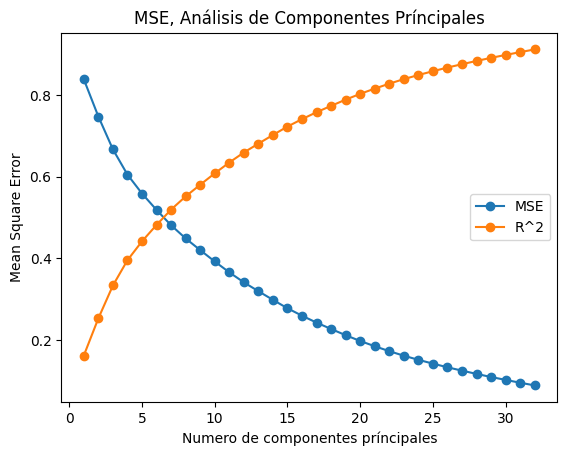

In [31]:
plt.plot(mses[:,0],mses[:,1],'-o',label='MSE')
plt.plot(mses[:,0],1.0-mses[:,1],'-o',label='R^2')

plt.title('MSE, Análisis de Componentes Príncipales')
plt.xlabel('Numero de componentes príncipales')
plt.ylabel('Mean Square Error')

plt.legend(loc='best')

plt.show()

**Análisis**:
Los resultados muestran que para obtener un R^2 de por lo menos e 80%, se requiere utilizar 20 componentes principales, lo cual implica que, aún se estaría reduciendo la dimensión del problema significativamente. Recordemos que, con 20 componentes, según los resultados discutidos anteriormente, se estaría explicando un 80.6% de la varianza total. La gráfica que se construye a continuación, nos presenta un paralelo de estas dos medidas de desempeño y muestra nuevamente que, la reducción de dimensiones se puede realizar sin una perdida significativa de información, porque el analista puede escoger el nivel con el cual, quiere trabajar y así, determinar el número de componentes a utilizar.

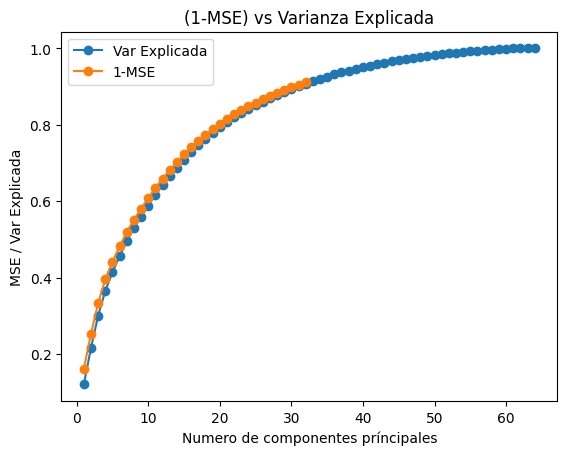

In [32]:
plt.plot(range(1,len(explained_variance)+1),np.cumsum(explained_variance),
         '-o',label='Var Explicada')
plt.plot(mses[:,0],1.0-mses[:,1],'-o',label='1-MSE')

plt.title('(1-MSE) vs Varianza Explicada')
plt.xlabel('Numero de componentes príncipales')
plt.ylabel('MSE / Var Explicada')
plt.legend(loc='best')
plt.show()